# Signal Processing for Machine Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lasseufpa/dsp/blob/main/guided_projects/proj2_fixed_point_filtering.ipynb)

The project is about digital filtering using fixed-point number representation. The goal is to mitigate noise and interference of
a single EEG waveform. The noise is AWGN ("additive, white and Gaussian noise") and the interference is at 60 Hz. It is assumed that the frequency band of interest in EEG analysis is from 0 to 40 Hz.

The assumed "hardware" is a DSP processor that uses an accumulator (acc) of
16 bits with saturation implemented, and all other numbers are represented in 8 bits.

The designer is allowed to work with the following degrees of freedom:

1) Any fixed-point representation can be used given that only numbers of 8 bits are used, with the exception of the acc with 16 bits. In other words, the assumed hardware restrictions must be respected. But the designer can use Q2.5 representation at some point of the DSP pipeline, and Q3.4 at another, for instance.
2) Any filter order can be used, and any implementation (direct form, sos sections, etc.)


> If you have just clicked the Google Colab Badge from GitHub, it not possible to save changes. Go to ``File > Save a copy in Drive`` to make a copy of this Jupyter notebook in your Google Drive storage, where changes can be saved, or ``File > Download > Download .ipynb`` to download this notebook to your computer.

# Load file

Learn:
* how to load and process a file from the EEG dataset
* use Python modules from packages that are not part of a well-known library, to train using (and later creating your own) a customized library. In this case it will be lasse-py.

In [1]:
!pip install mne

# =========================================
# Clone repo
# =========================================
!git clone https://github.com/lasseufpa/lasse-py.git

# Move into repo
%cd lasse-py

# =========================================
# Install as editable package
# =========================================
!pip install -e .

# =========================================
# (Optional) Verify installation
# =========================================
import importlib

try:
    import lasse
    print("lasse package found at:", lasse.__file__)
except Exception as e:
    print("Import failed:", e)

# =========================================
# Test your specific import
# =========================================
from lasse.dsp.fixed_point_dsp import quantize_array
from lasse.dsp.fixed_point_dsp import compare_frequency_responses
from lasse.dsp.fixed_point_dsp import apply_fixed_point_filter
from lasse.dsp.fixed_point_dsp import apply_fixed_point_filter_int8
from lasse.dsp.fixed_point_dsp import check_realtime_difference_equation
from lasse.dsp.fixed_point_dsp import does_FIR_have_symmetry

print("Imports successful.")

c:\github\dsp\guided_projects\lasse-py


Cloning into 'lasse-py'...


Obtaining file:///C:/github/dsp/guided_projects/lasse-py
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for lasse-py (pyproject.toml): started
  Building editable for lasse-py (pyproject.toml): finished with status 'done'
  Created wheel for lasse-py: filename=lasse_py-0.0.1-0.editable-py3-none-any.whl size=15264 sha256=cf2d58170b7707f841d8222814fafb9f69dc4e645ade81a51173bad2a38779ec
  Stored in directory: C:\Users\abrkl\AppData\Local\Temp\pip-ephem-wheel-cache-jrb4bjh_\wheels\26\c4\40\e694707434766070782ae76cad4d89ed33553366

In [ ]:
if False:
    # during development, while changing lasse-py, to avoid restarting the kernel, use autoreload
    %load_ext autoreload
    %autoreload 2

    #!git -C /content/lasse-py pull

    import inspect
    from lasse.dsp.fixed_point_dsp import apply_fixed_point_filter_int8

    print(inspect.getsourcefile(apply_fixed_point_filter_int8))
    print(inspect.signature(apply_fixed_point_filter_int8))

In [52]:
# Define "global" variables
INTERFERENCE_POWER = 1e-6  # Power of the 60 Hz interference to be added to the EEG signal
USE_FIR = True # If True, we will design and use a FIR filter. If False, we will design and use an IIR filter.
ACC_NUM_BITS = 16 # Number of bits to use in the fixed-point filter output accumulator. This is the assumed value and cannot be changed.
ACC_FRACTIONAL_BITS = 8 # Number of fractional bits to use in the fixed-point filter output accumulator. This is the assumed value and cannot be changed.

In [53]:
import math
from typing import Any, Literal, cast

import plotly.graph_objects as go

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from scipy.signal import butter, freqz, lfilter, dimpulse

import urllib.request
import mne
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from scipy.signal import butter, lfilter

import numpy as np

import numpy as np
from scipy.signal import firwin, lfilter



# Methods to plot / visualize time-domain waveforms and PSDs

In [54]:
def plot_waveform_continuous_time(x, title="Waveform"):
    """
    Plot the waveform of a signal.
    """
    plt.plot(x)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude (V)")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_waveform_discrete_time(x, title="Waveform"):
    """
    Plot the waveform of a signal.
    """
    plt.stem(x)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude (V)")
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_psd(x, Fs, nperseg=None, title="Power Spectral Density"):
    """
    Plot power spectral density (PSD) using Welch's method.

    Parameters
    ----------
    x : ndarray
        Signal samples.
    Fs : float
        Sampling frequency in Hz.
    nperseg : int, optional
        Segment length for Welch's method.
        Default: min(1024, len(x)).
    """
    if nperseg is None:
        nperseg = min(1024, len(x))

    f, Pxx = welch(
        x,
        fs=Fs,
        window='hann',
        nperseg=nperseg,
        detrend='constant',
        scaling='density'
    )

    plt.figure(figsize=(8, 4))
    plt.semilogy(f, Pxx)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (watts/Hz)')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# Method to compare two signals that may be delayed and distorted with respect to each other

In [55]:
def compare_signals(x_ref, x_test, max_lag=None, normalize_gain=True):
    """
    Compare x_test against x_ref after delay alignment and optional gain normalization.

    Parameters
    ----------
    x_ref : ndarray
        Reference clean signal.
    x_test : ndarray
        Noisy or filtered signal to compare.
    max_lag : int or None
        Maximum lag, in samples, searched during alignment.
        If None, uses len(x_ref)//2.
    normalize_gain : bool
        If True, scales x_test to best match x_ref in least-squares sense.

    Returns
    -------
    mse : float
        Mean squared error after alignment.
    SNRdB : float
        Signal-to-error ratio in dB.
    lag : int
        Estimated delay of x_test relative to x_ref.
    gain : float
        Applied gain factor to x_test.
    x_ref_aligned : ndarray
        Cropped reference signal.
    x_test_aligned : ndarray
        Aligned and optionally gain-normalized test signal.
    """

    x_ref = np.asarray(x_ref).flatten()
    x_test = np.asarray(x_test).flatten()

    if len(x_ref) != len(x_test):
        raise ValueError("x_ref and x_test must have the same length.")

    N = len(x_ref)

    if max_lag is None:
        max_lag = N // 2

    lags = np.arange(-max_lag, max_lag + 1)
    corr = np.zeros(len(lags))

    for i, lag in enumerate(lags):
        if lag >= 0:
            xr = x_ref[lag:]
            xt = x_test[:N-lag]
        else:
            xr = x_ref[:N+lag]
            xt = x_test[-lag:]

        corr[i] = np.sum(xr * xt)

    lag = lags[np.argmax(np.abs(corr))]

    if lag >= 0:
        x_ref_aligned = x_ref[lag:]
        x_test_aligned = x_test[:N-lag]
    else:
        x_ref_aligned = x_ref[:N+lag]
        x_test_aligned = x_test[-lag:]

    if normalize_gain:
        gain = np.dot(x_ref_aligned, x_test_aligned) / \
            np.dot(x_test_aligned, x_test_aligned)
        x_test_aligned = gain * x_test_aligned
    else:
        gain = 1.0

    error = x_ref_aligned - x_test_aligned

    mse = np.mean(error**2)

    SNRdB = 10 * np.log10(
        np.mean(x_ref_aligned**2) / np.mean(error**2)
    )

    print(f"  MSE = {mse:.6e}")
    print(f"  SNR = {SNRdB:.2f} dB")
    print(f"  lag = {lag} samples")
    print(f"  gain = {gain:.4f}")

    # x_test_aligned is the version of x_test that is aligned in time and scaled in amplitude to best match x_ref_aligned.
    # We return these aligned versions for later plotting.
    return x_test_aligned, x_ref_aligned



# Design a good digital filter

Here each team should try new filters.

In [56]:
def design_lowpass_filter_fir(Fs, fc=40.0, order=100):
    """
    Causal FIR lowpass filter.

    Parameters
    ----------
    Fs : float
        Sampling frequency in Hz.
    fc : float
        Cutoff frequency in Hz.
    order : int (prefer even), optional
        Filter order. The number of FIR coefficients will be order + 1.

    Returns
    -------
    y : ndarray
        Filtered signal.
    h : ndarray
        FIR impulse response.
    delay : int
        Nominal group delay in samples.
    """
    numtaps = order + 1
    h = firwin(
        numtaps,
        fc,
        window="hamming",
        fs=Fs
    )

    # Because this is a linear-phase FIR, the group delay is approximately constant:
    delay = (numtaps - 1) // 2
    print(
        f"FIR filter designed with {numtaps} coefficients, nominal group delay = {delay} samples")

    # Coefficients B(z) of a FIR coincide with the impulse response h[n]
    Bz = h
    Az = np.array([1.0]) # FIR filter has only feedforward coefficients, so A(z) = 1
    return Bz, Az


def design_lowpass_filter_iir  (Fs: float, fc: float = 40.0, order: int = 4):
    # Detail: Pylance complains with Butter, so use ignore[reportGeneralTypeIssues] below:
    Bz, Az = butter(  # type: ignore[reportGeneralTypeIssues]
        order,
        fc,
        btype="low",
        output="ba",
        fs=Fs
    )

    return Bz, Az




# Methods to add noise and interference

In [57]:
def add_60Hz_interference(x, Fs, interference_power, phase=0.0):
    """
    Add a 60 Hz sinusoidal interference to signal x with a given power.

    Parameters
    ----------
    x : ndarray
        Input signal.
    Fs : float
        Sampling frequency in Hz.
    interference_power : float
        Power of the 60 Hz interference.
    phase : float, optional
        Initial phase in radians.

    Returns
    -------
    y : ndarray
        Signal plus interference.
    interference : ndarray
        Generated 60 Hz interference.
    """
    x = np.asarray(x)

    N = len(x)
    t = np.arange(N) / Fs

    # Signal power
    signal_power = np.mean(x**2)

    # Sinusoids have power A^2/2
    amplitude = np.sqrt(2 * interference_power)

    interference = amplitude * np.cos(
        2 * np.pi * 60 * t + phase
    )

    y = x + interference

    SNRdB = 10 * np.log10(signal_power / interference_power)
    print("Signal power = ", signal_power, "watts")
    print(f"Added 60 Hz interference with power {interference_power:<10.6f} watts, resulting in SNR = {SNRdB:<10.2f} dB.")

    return y, interference


def add_noise(x, SNRdB, seed=None):
    """
    Add AWGN to signal x for a target SNR in dB.
    """
    if seed is not None:
        np.random.seed(seed)

    x = np.asarray(x)
    signal_power = np.mean(np.abs(x)**2)
    noise_power = signal_power / (10**(SNRdB/10))

    noise = np.sqrt(noise_power) * np.random.randn(*x.shape)
    return x + noise, noise

# Code to help planning quantization and fixed point Qm.n format

In [58]:
def show_statistics_to_plan_quantization(
        p: np.ndarray,
        array_name: str = "Array"):
    '''
    Show statistics of an array to plan quantization.
    '''

    p = np.asarray(p)

    print(f"Statistics of {array_name}:")
    print(f"  min = {p.min():.6e}")
    print(f"  max = {p.max():.6e}")

    max_abs = np.max(np.abs(p))

    nonzero = np.abs(p[p != 0])

    if len(nonzero) == 0:
        print("  array contains only zeros")
        return

    min_nonzero_abs = np.min(nonzero)

    print(f"  maximum absolute value = {max_abs:.6e}")
    print(f"  minimum nonzero absolute value = {min_nonzero_abs:.6e}")

    # integer bits (including sign)
    integer_bits = max(1, math.ceil(math.log2(max_abs)) + 1)

    # fractional bits
    fractional_bits = max(0, math.ceil(-math.log2(min_nonzero_abs)))

    total_bits = integer_bits + fractional_bits

    print(f"  integer bits (including sign): {integer_bits}")
    print(f"  fractional bits: {fractional_bits}")
    print(f"  total bits: {total_bits}")
    print(f"  suggested fixed-point format: "
          f"Q{integer_bits-1}.{fractional_bits}")

# Load EEG signal

Original sampling frequency: 160.0 Hz
Statistics of Original EEG signal:
  min = -2.320000e-04
  max = 3.970000e-04
  maximum absolute value = 3.970000e-04
  minimum nonzero absolute value = 1.000000e-06
  integer bits (including sign): 1
  fractional bits: 20
  total bits: 21
  suggested fixed-point format: Q0.20


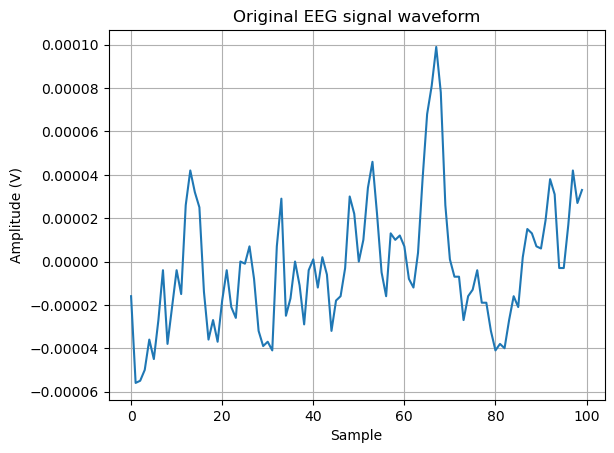

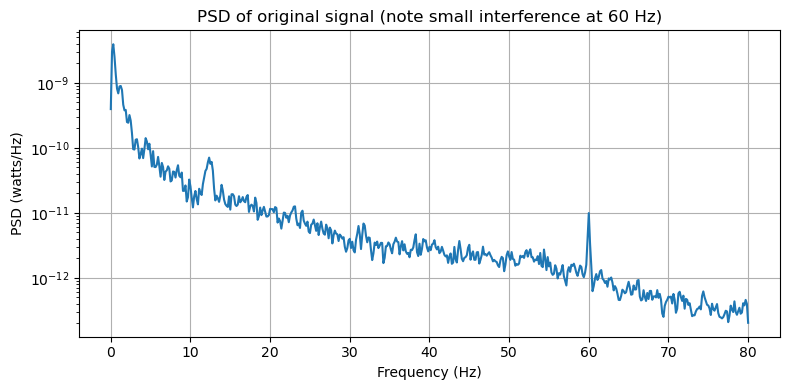

In [59]:
url = "https://physionet.org/files/eegmmidb/1.0.0/S001/S001R01.edf"
filename = "S001R01.edf"

urllib.request.urlretrieve(url, filename)

raw = mne.io.read_raw_edf(filename, preload=True, verbose=False)

sampling_frequency = raw.info["sfreq"]
z = raw.get_data(picks=[0])[0]   # first EEG channel, in volts

print("Original sampling frequency:", sampling_frequency, "Hz")

show_statistics_to_plan_quantization(z, array_name="Original EEG signal")

plot_waveform_continuous_time(z[:100], title="Original EEG signal waveform")
plot_psd(z, sampling_frequency, title="PSD of original signal (note small interference at 60 Hz)")

# Add AWGN noise and interference at 60 Hz

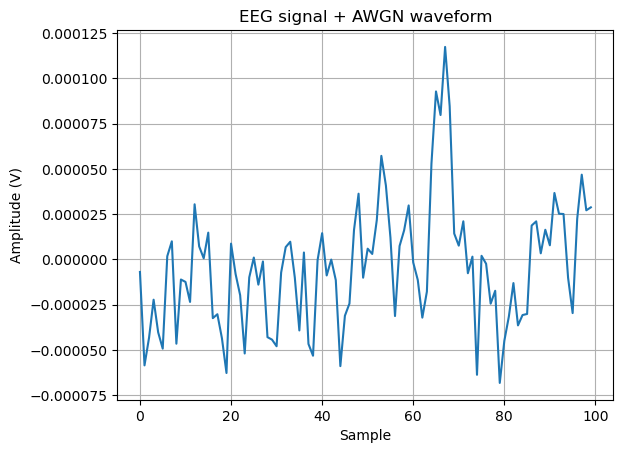

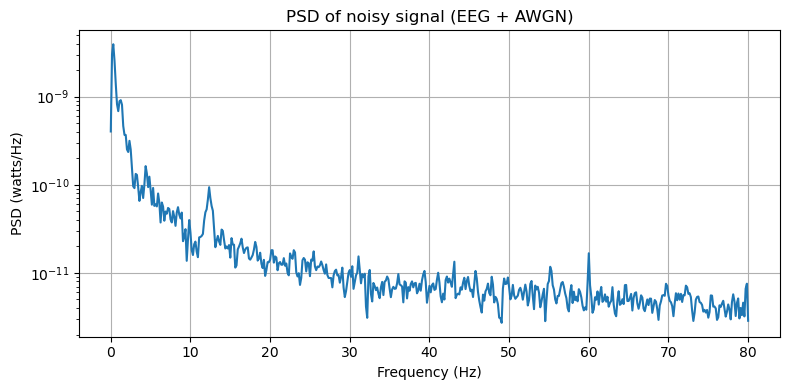

Comparing original clean signal z with noisy (AWGN) signal y:
  MSE = 3.019547e-10
  SNR = 10.41 dB
  lag = 0 samples
  gain = 0.9059
Signal power =  3.674197867338338e-09 watts
Added 60 Hz interference with power 0.000001   watts, resulting in SNR = -24.35     dB.


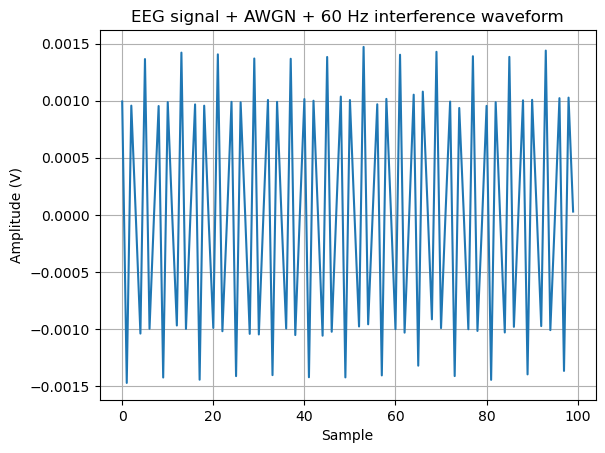

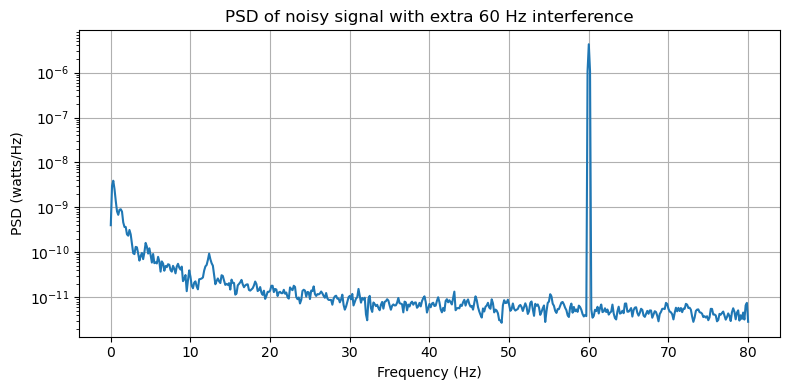

Comparing original clean signal z with noisy (AWGN+interference) signal x:
  MSE = 3.301897e-09
  SNR = 0.02 dB
  lag = -1 samples
  gain = 0.0039


In [60]:
# add WGN with a given SNR in dB and 60 Hz interference with SIR of -3 dB
y = add_noise(z, SNRdB=10, seed=42)[0]

plot_waveform_continuous_time(y[:100], title="EEG signal + AWGN waveform")
plot_psd(y, sampling_frequency, title="PSD of noisy signal (EEG + AWGN)")

# compare original clean signal z with noisy signal y
print("Comparing original clean signal z with noisy (AWGN) signal y:")
y_normalized, z_aligned = compare_signals(z, y)

# now we add the 60 Hz interference to the noisy signal y
x = add_60Hz_interference(y, Fs=sampling_frequency, interference_power=INTERFERENCE_POWER, phase=np.pi/4)[0]

plot_waveform_continuous_time(x[:100], title="EEG signal + AWGN + 60 Hz interference waveform")
plot_psd(x, sampling_frequency, title="PSD of noisy signal with extra 60 Hz interference")

print("Comparing original clean signal z with noisy (AWGN+interference) signal x:")
y_normalized, x_aligned = compare_signals(z, x)

In [61]:
# normalize to later quantize signal x
eeg_normalization_factor = np.max(np.abs(x))
x_normalized = x / eeg_normalization_factor

In [62]:
print("EEG normalization factor:", eeg_normalization_factor)
show_statistics_to_plan_quantization(x_normalized, array_name="Normalized and noisy EEG signal")

EEG normalization factor: 0.0017185208409874688
Statistics of Normalized and noisy EEG signal:
  min = -9.484434e-01
  max = 1.000000e+00
  maximum absolute value = 1.000000e+00
  minimum nonzero absolute value = 3.602576e-05
  integer bits (including sign): 1
  fractional bits: 15
  total bits: 16
  suggested fixed-point format: Q0.15


# Quantize the input signal

In [63]:
def quantize_input_and_save(x, filename):
    total_bits = 8
    frac_bits = 7
    x_q, x_i = quantize_array(x, total_bits, frac_bits, mode="round")
    np.savetxt(filename, x_i, fmt="%d")
    return x_q, x_i

# Save xi to a text file for later use in fixed-point filtering
x_normalized_q, x_normalized_i = quantize_input_and_save(x_normalized, "x_quantized.txt")

print("Comparing x_normalized and its quantized version xq:")
compare_signals(x_normalized, x_normalized_q)

Warning! Consider increasing number of bits to represent the integer part (b-1-b_f)
Comparing x_normalized and its quantized version xq:
  MSE = 5.023314e-06
  SNR = 48.30 dB
  lag = 0 samples
  gain = 1.0000


(array([ 0.57812154, -0.85936986,  0.55468418, ...,  0.82030759,
        -0.58593399, -0.00781245]),
 array([ 0.57784944, -0.85697632,  0.55675548, ...,  0.81767156,
        -0.58323811, -0.00584054]))

# Design a filter, and evaluate how to quantize its coefficients

FIR filter designed with 101 coefficients, nominal group delay = 50 samples
Statistics of Numerator filter coefficients (Bz):
  min = -1.051858e-01
  max = 4.997485e-01
  maximum absolute value = 4.997485e-01
  minimum nonzero absolute value = 2.499877e-19
  integer bits (including sign): 1
  fractional bits: 62
  total bits: 63
  suggested fixed-point format: Q0.62
Numerator filter coefficients (Bz): [-2.49987663e-19  5.25321769e-04 -1.62914673e-18 -5.96685568e-04
  4.16085295e-18  7.24773444e-04 -7.95756411e-18 -9.15824084e-04
 -1.01725917e-18  1.17644916e-03 -3.26993745e-18 -1.51377211e-03
  1.00752338e-17  1.93562597e-03 -4.80763124e-18 -2.45083287e-03
 -4.03968672e-18  3.06959861e-03 -6.70423968e-18 -3.80407257e-03
  2.27402576e-17  4.66915104e-03 -8.84059186e-18 -5.68364775e-03
 -1.22626170e-17  6.87203475e-03 -1.10824529e-17 -8.26709775e-03
  4.43710161e-17  9.91411225e-03 -1.32889585e-17 -1.18776573e-02
  1.43352987e-17  1.42532343e-02 -1.53214658e-17 -1.71881725e-02
  1.623190

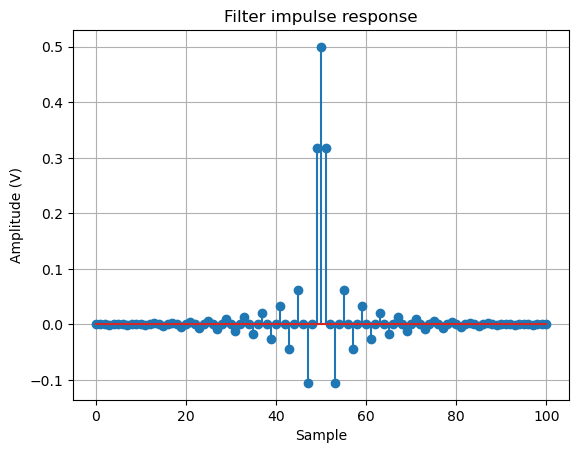

In [64]:
if USE_FIR:
    Bz, Az = design_lowpass_filter_fir(Fs=sampling_frequency, fc=40.0, order=100)
else:
    Bz, Az = design_lowpass_filter_iir(Fs=sampling_frequency, fc=40.0, order=6)

show_statistics_to_plan_quantization(Bz, "Numerator filter coefficients (Bz)")
print("Numerator filter coefficients (Bz):", Bz)

# plot impulse response of the filter
if USE_FIR:
    hn = Bz # FIR filter impulse response is just the coefficients Bz
else:
    # find impulse response of IIR filter using sicpy.signal.dimpulse
    _, hn_tuple = dimpulse((Bz, Az, 1), n=100)
    # scipy.signal.dimpulse() returns hn as a tuple of arrays, not directly an array.
    hn = np.squeeze(hn_tuple[0]) # remove extra dimensions and convert to a 1-D array and ignore: # type: ignore[reportOptionalSubscript]

plot_waveform_discrete_time(hn, title="Filter impulse response")

# if it's an IIR filter, quantize A(z) coefficients, but do not quantize the leading 1 in Az[0]
if not USE_FIR:
    Az = np.array(Az) # make sure it's a numpy array so we can do elementwise operations
    # make sure Az[0] is 1 (it should be for a proper IIR filter)
    if Az[0] != 1.0:
        print("Warning: Az[0] was not 1. I am now normalizing filter coefficients.")
        Bz = Bz / Az[0]
        Az = Az / Az[0]
    # we do not quantize the leading 1 in Az, but we still want to know how many bits we need for the other coefficients in Az
    show_statistics_to_plan_quantization(Az[1:], "Denominator filter coefficients (Az) excluding leading Az[0]")
    print("Denominator filter coefficients (Az):", Az)

# Compare two methods for filtering using "infinite" precision

Here the filter coefficientes are not quantized, only the input signal.

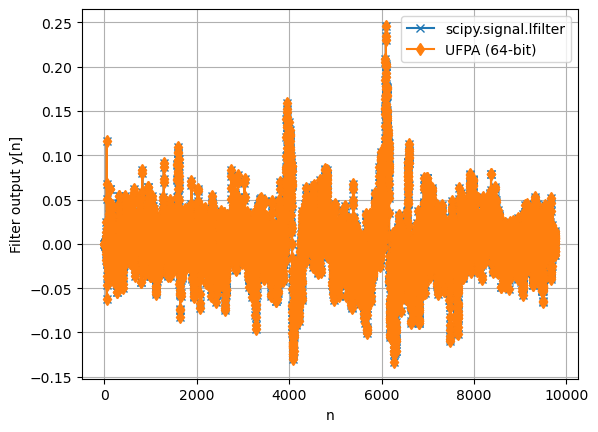

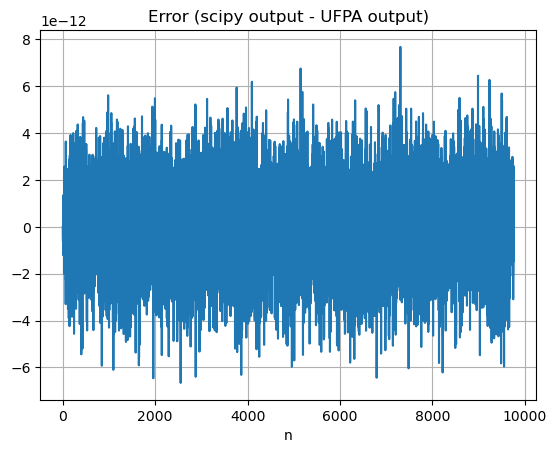

In [65]:
# filter using scipy
y_scipy = np.asarray(lfilter(Bz, Az, x_normalized_q), dtype=np.float64)

# use our method for fixed-point filtering, but use very large number of bits
y_ufpa_large_number_of_bits = apply_fixed_point_filter(
        Bz,
        Az,
        x_normalized_q,
        total_bits=64,
        frac_bits=40,
        acc_bits=64,
        acc_frac_bits=40,
        mode="round",
    )

should_plot = True
if should_plot:
    n = np.arange(len(x_normalized_q))
    plt.figure()
    plt.plot(n, y_scipy, "x-", label="scipy.signal.lfilter")
    plt.plot(n, y_ufpa_large_number_of_bits, "d-", label="UFPA (64-bit)")
    plt.xlabel("n")
    plt.ylabel("Filter output y[n]")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(n, y_scipy - y_ufpa_large_number_of_bits)
    plt.xlabel("n")
    plt.title("Error (scipy output - UFPA output)")
    plt.grid(True)
    plt.show()

# Compare filtered signal with original EEG version, before quantizing the input and adding noise + interference

Power of original clean signal z: 3.316879918032786e-09 watts
Power of scipy-filtered signal y_scipy: 3.4567499047635152e-09 watts
  MSE = 2.098802e-10
  SNR = 12.01 dB
  lag = -50 samples
  gain = 0.9491


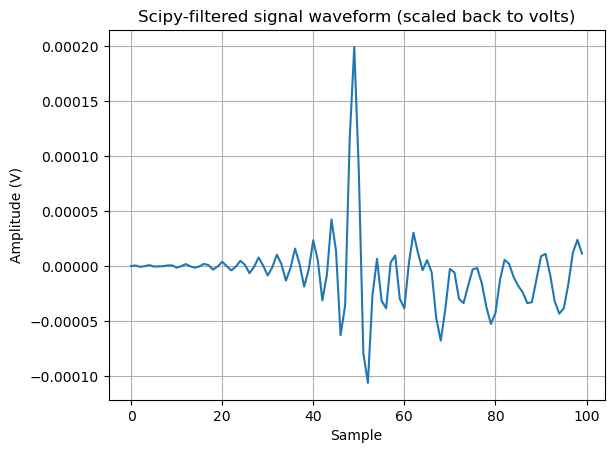

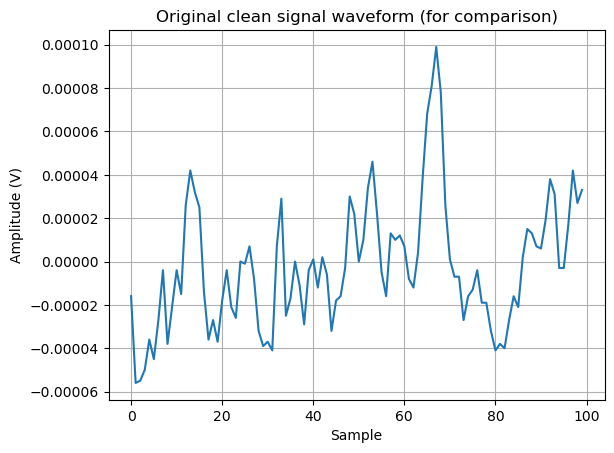

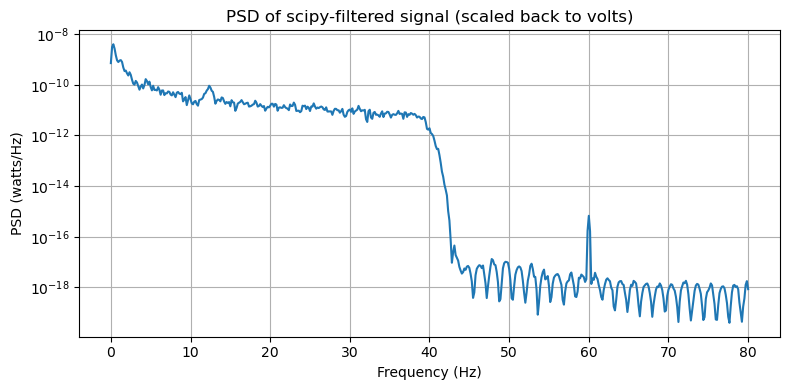

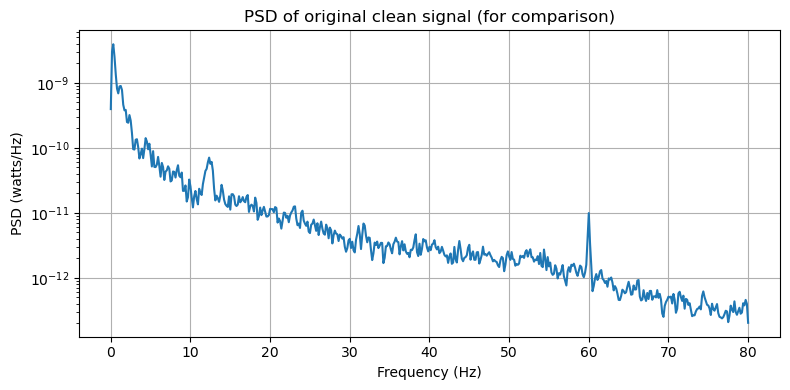

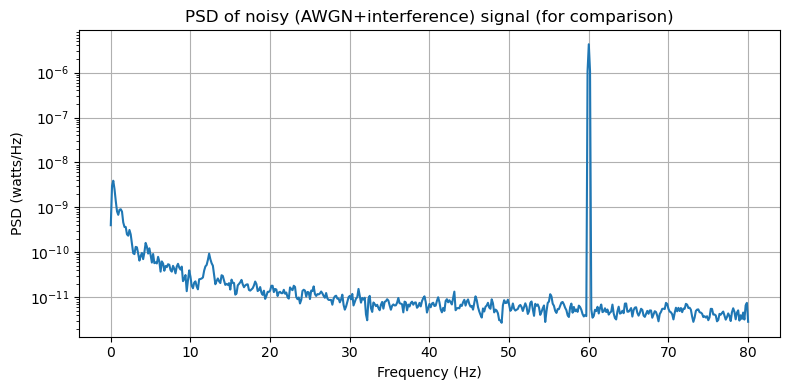

In [66]:
# the method compare_signals() implements normalization, but we can also do ourselves:
y_scipy_normalized = y_scipy * eeg_normalization_factor # scale back to original units of volts
print("Power of original clean signal z:", np.mean(z**2), "watts")
print("Power of scipy-filtered signal y_scipy:", np.mean(y_scipy_normalized**2), "watts")

compare_signals(z, y_scipy_normalized)

plot_waveform_continuous_time(y_scipy_normalized[:100], title="Scipy-filtered signal waveform (scaled back to volts)")
plot_waveform_continuous_time(z[:100], title="Original clean signal waveform (for comparison)")
plot_psd(y_scipy_normalized, sampling_frequency, title="PSD of scipy-filtered signal (scaled back to volts)")
plot_psd(z, sampling_frequency, title="PSD of original clean signal (for comparison)")
plot_psd(x, sampling_frequency, title="PSD of noisy (AWGN+interference) signal (for comparison)")


# Quantization: now we effectively quantize the filter

In [67]:
def quantize_filter_coefficients(Bz, Az, use_FIR=True):
    '''
    The project demands using 8 bits per coefficient. But you can choose different Qm.n formats for the coefficients.
    Below, I am using Q4.3 coefficients
    '''
    total_bits = 8

    # You may try tricks
    # Trick 1:
    # we may choose different numbers of fractional bits for B(z) and A(z),
    # but then we need to make sure we take that in account to
    # implement the adequate difference equation in apply_fixed_point_filter() and apply_fixed_point_filter_int8()

    # Trick 2:
    # based on my investigation of the statistics of Bz, before quantizing, I will first multiply B(z)
    # by a factor, and then later I will divide the output of the filter by this factor to compensate for that.
    gain_factor_Bz = 2.0

    frac_bits_Bz = 7 # An arbitrary choice. Choose better!
    scaled_Bz = gain_factor_Bz * Bz
    Bq, Bi = quantize_array(scaled_Bz, total_bits, frac_bits_Bz, mode="round")

    if np.sum(np.abs(Bq)) == 0:
        raise RuntimeError("Quantized filter has B(z) only with zero values.")

    if not use_FIR: # IIR filter
        frac_bits_Az = 6 # An arbitrary choice. Choose better!

        # We do NOT apply gain_factor_Bz to Az because it would modify the poles
        # We exclude the leading Az[0] from below:
        Aq_tail, Ai_tail = quantize_array(Az[1:], total_bits, frac_bits_Az, mode="round")

        Aq = np.concatenate(([1.0], Aq_tail))
        # Because Ai is the integer representation of the quantized coefficients, then the leading denominator coefficient Az[0]=1
        # is represented as the integer 2**frac_bits_Az. For example, if frac_bits_Az = 4, then Az[0]=1 is represented as the integer 16 in Ai.
        Ai = np.concatenate(([2**frac_bits_Az], Ai_tail))

        if np.sum(np.abs(Aq[1:])) == 0:
            raise RuntimeError("Quantized filter has all feedback coefficients A(z) equal to zero.")
    else:
        Aq = np.array([1.0])
        Ai = np.array([2**frac_bits_Bz])

    return Bq, Bi, Aq, Ai

# Quantize and compare frequency responses

Warning! Consider increasing number of bits to represent the integer part (b-1-b_f)


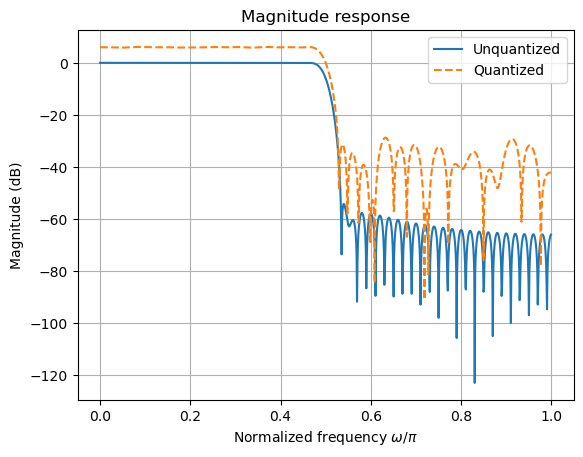

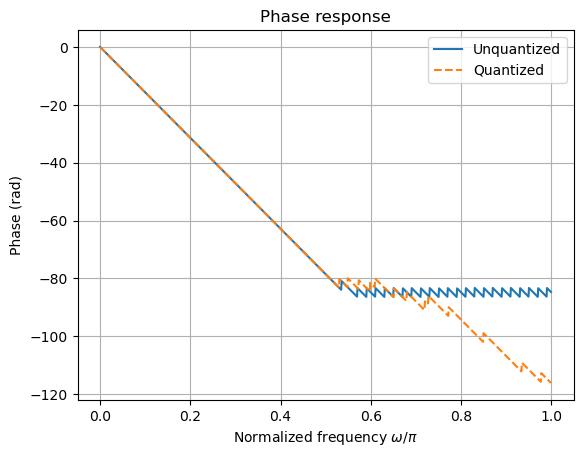

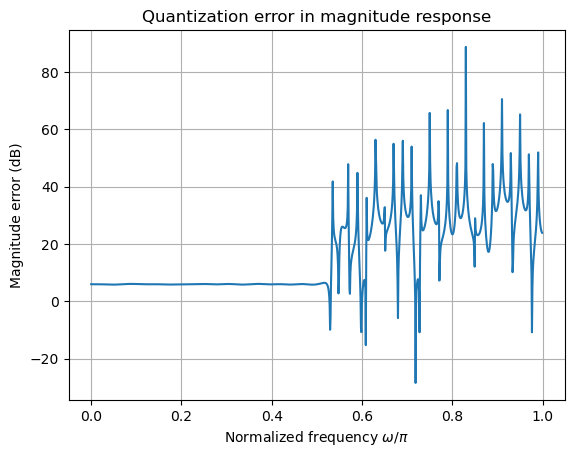

In [68]:
Bq, Bi, Aq, Ai = quantize_filter_coefficients(Bz, Az, use_FIR=USE_FIR)

w, H, Hq = compare_frequency_responses(Bz, Az, Bq, Aq)

# Perform fixed-point filtering using method apply_fixed_point_filter_int8()

In [69]:
Bi = np.asarray(Bi, dtype=np.int8)
Ai = np.asarray(Ai, dtype=np.int8)
x_normalized_i = np.asarray(x_normalized_i, dtype=np.int8)

y_int8_i, y_int8_q = apply_fixed_point_filter_int8(
        Bi, Ai, x_normalized_i, acc_frac_bits=ACC_FRACTIONAL_BITS, mode="round")

# save y_int8_i to text file for later use in comparison with scipy output
np.savetxt("y_int8_i.txt", y_int8_i, fmt="%d")

should_plot = True
if should_plot:
    # compare with original signal
    fig = go.Figure()
    fig.add_scatter(x=n, y=y_int8_q,
                    mode='lines', name='apply_fixed_point_filter_int8()')
    fig.add_scatter(x=n, y=y_scipy,
                    mode='lines+markers', name='scipy.signal.lfilter')
    # Adding the figure title and axes titles
    fig.update_layout(
        title="Comparison of apply_fixed_point_filter_int8() and scipy.signal.lfilter() outputs",
        xaxis_title="Sample Number",
        yaxis_title="Amplitude"
    )
    fig.show()

    # normalize to later plot the waveforms superimposed
    amplitude_ratio = np.mean(np.abs(y_int8_i) / np.mean(np.abs(y_int8_q)))
    print(f"Amplitude ratio (): {amplitude_ratio}")

    scaled_quantized_output = y_int8_q * amplitude_ratio

    fig = go.Figure()
    fig.add_scatter(x=n, y=scaled_quantized_output,
                    mode='lines+markers', name='y_int8_q quantized output',
                    marker=dict(symbol='square', size=8, color='blue'))
    fig.add_scatter(x=n, y=y_int8_i,
                    mode='lines+markers', name='y_int8_q integer indices')
    fig.update_layout(
        title="Comparison of apply_fixed_point_filter_int8() output in quantized units and its decoded version in volts",
        xaxis_title="Sample Number",
        yaxis_title="Amplitude"
    )
    fig.show()

 B_i.dtype: int8 A_i.dtype: int8 x_i.dtype: int8


Amplitude ratio (): 255.99999999999994


# Optional: investigate another method to perform fixed-point filtering

In this project, using the method apply_fixed_point_filter() is not necessary.

In [70]:
should_show_other_quantization_results = False
if should_show_other_quantization_results:
    # The method apply_fixed_point_filter uses the same fixed-point representation with total_bits and frac_bits to:
    # a) input x, and b) coefficients B and A.
    # It uses the quantized values, not the integer representations.
    total_bits_all = 8
    frac_bits_all = 7
    y_ufpa_small_number_of_bits = apply_fixed_point_filter(
            Bq,
            Aq,
            x_normalized_q,
            total_bits=total_bits_all,
            frac_bits=frac_bits_all,
            acc_bits=ACC_NUM_BITS,
            acc_frac_bits=ACC_FRACTIONAL_BITS,
            mode="round",
        )

    should_plot = True
    if should_plot:
        fig = go.Figure()
        fig.add_scatter(x=n, y=y_ufpa_small_number_of_bits,
                        mode='lines', name='apply_fixed_point_filter()')
        fig.add_scatter(x=n, y=y_int8_q,
                        mode='lines', name='apply_fixed_point_filter_int8()')
        fig.add_scatter(x=n, y=y_scipy,
                        mode='lines+markers', name='scipy.signal.lfilter')
        fig.show()

# Final comparison to get SNR

Quantization step in volts: 7.812500e-03 V
Power of original clean signal z: 3.316879918032786e-09 watts
Power of fixed-point filtered signal y_int8_final: 8.960716552353392e-10 watts
  MSE = 3.351827e-10
  SNR = 9.98 dB
  lag = -50 samples
  gain = 1.8264


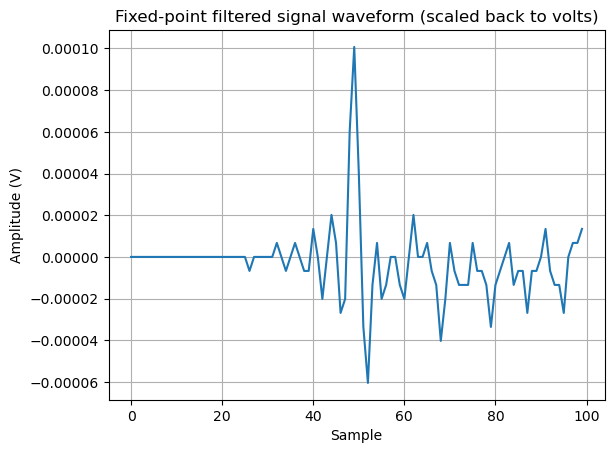

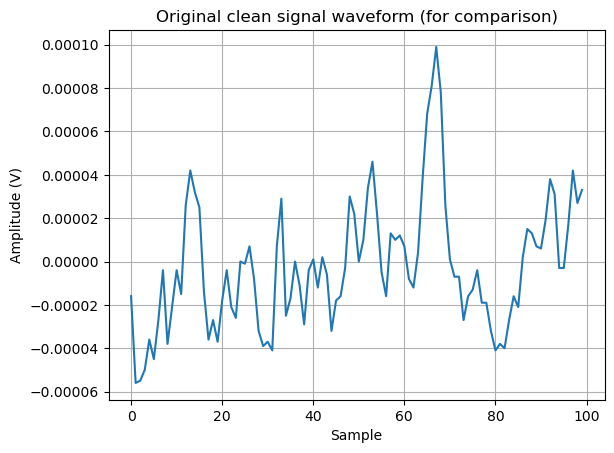

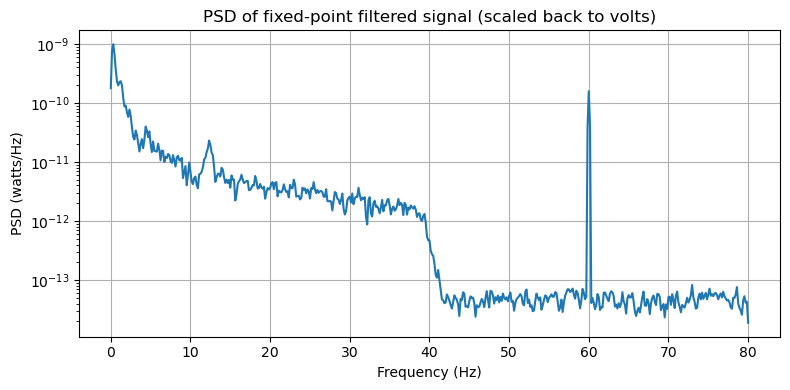

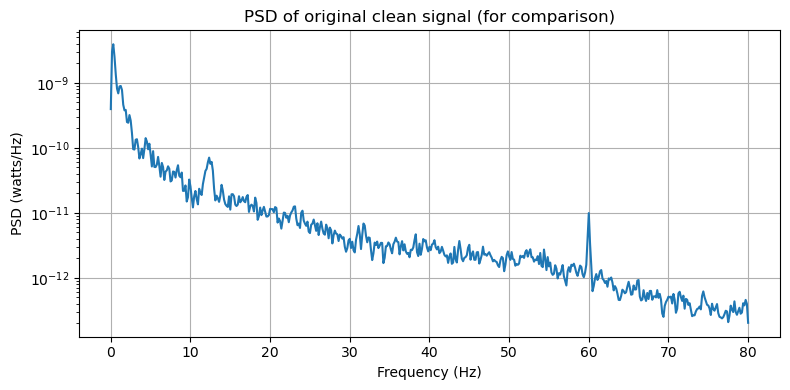

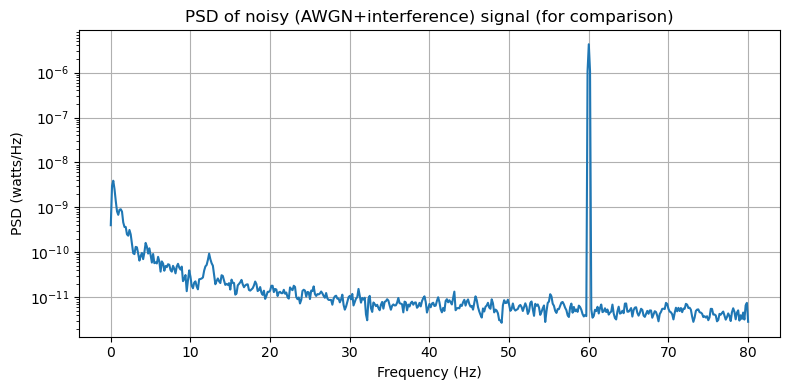

In [71]:
# the method compare_signals() implements normalization, but we can also normalize ourselves:
bits_used_to_quantize_input = 7
quantization_step = 1 / (2**bits_used_to_quantize_input)
print(f"Quantization step in volts: {quantization_step:.6e} V")
y_int8_final = y_int8_i * quantization_step

# now take in account the gain factor we used in x_normalized = x / eeg_normalization_factor
# that we applied to the input signal before quantizing it
y_int8_final = y_int8_final * eeg_normalization_factor

# take in account the factor of 2.0 that we applied to the filter coefficients before quantizing them
y_int8_final = y_int8_final / 2.0 # scale back to original units of volts

print("Power of original clean signal z:", np.mean(z**2), "watts")
print("Power of fixed-point filtered signal y_int8_final:", np.mean(y_int8_final**2), "watts")

y_int8_final_normalized = compare_signals(z, y_int8_final)

plot_waveform_continuous_time(y_int8_final[:100], title="Fixed-point filtered signal waveform (scaled back to volts)")
plot_waveform_continuous_time(z[:100], title="Original clean signal waveform (for comparison)")
plot_psd(y_int8_final, sampling_frequency, title="PSD of fixed-point filtered signal (scaled back to volts)")
plot_psd(z, sampling_frequency, title="PSD of original clean signal (for comparison)")
plot_psd(x, sampling_frequency, title="PSD of noisy (AWGN+interference) signal (for comparison)")

# Check the quality of your DSP processing by observing the input and output signals

Both signals are represented as 8 bits.

Statistics of Quantized input (integer representation):
  min = -1.210000e+02
  max = 1.270000e+02
  maximum absolute value = 1.270000e+02
  minimum nonzero absolute value = 1.000000e+00
  integer bits (including sign): 8
  fractional bits: 0
  total bits: 8
  suggested fixed-point format: Q7.0
Statistics of Quantized output (integer representation):
  min = -1.800000e+01
  max = 3.300000e+01
  maximum absolute value = 3.300000e+01
  minimum nonzero absolute value = 1.000000e+00
  integer bits (including sign): 7
  fractional bits: 0
  total bits: 7
  suggested fixed-point format: Q6.0


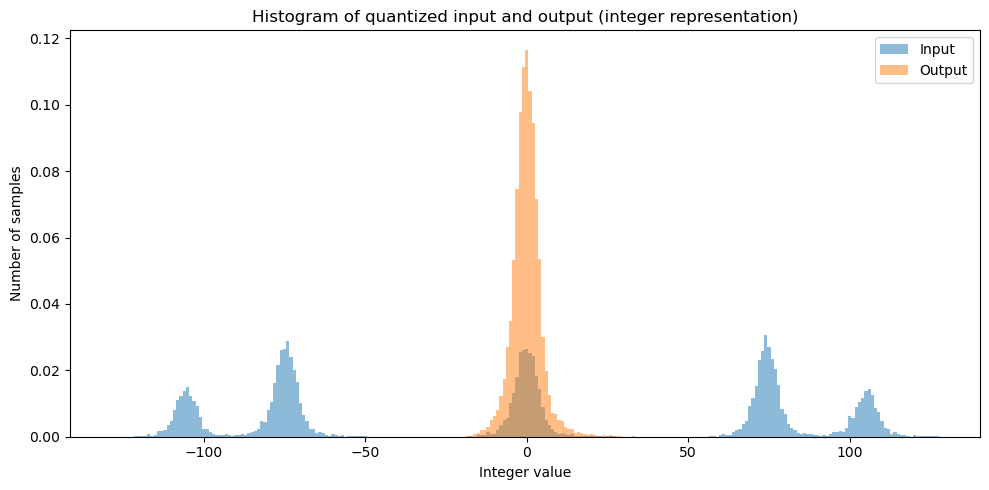

In [78]:


# load the txt files with the integer representations of the quantized input and output
x_int8 = np.loadtxt("x_quantized.txt", dtype=np.int8)
y_int8 = np.loadtxt("y_int8_i.txt", dtype=np.int8)

show_statistics_to_plan_quantization(x_int8, "Quantized input (integer representation)")
show_statistics_to_plan_quantization(y_int8, "Quantized output (integer representation)")

# Center bins on integer values
bins = np.arange(-128, 129) - 0.5

# plot their histograms superimposed to each other
plt.figure(figsize=(10, 5))
plt.hist(x_int8, bins=bins, density=True, alpha=0.5, label="Input")
plt.hist(y_int8, bins=bins, density=True, alpha=0.5, label="Output")
plt.xlabel("Integer value")
plt.ylabel("Number of samples")
# add legend to distinguish the two histograms
plt.legend()
plt.title("Histogram of quantized input and output (integer representation)")
plt.tight_layout()
plt.show()


# Check whether the DSP hardware can execute the digital filter in real-time

We will assume an Arduino Uno based on the 8-bit AVR ATmega328P running at 16 MHz. In this case, a reasonable order-of-magnitude estimate is that a MAC takes 1 μs. Actual values depend strongly on whether the code is written in C or assembly, the compiler optimization level, memory accesses, and whether saturation and scaling are included.
A hardware 8×8 multiplication on the AVR takes about 2 clock cycles, while the addition and register moves require a few more cycles. A carefully optimized assembly implementation can achieve a MAC in perhaps 5–10 cycles:
A C implementation with loop overhead, memory accesses, saturation, etc., will be slower. 

| Assumption                        | Approximate Tmax |
| --------------------------------- | --------------------- |
| Optimized assembly                | 0.3–0.6 μs            |
| Optimized C                       | 0.8–1.5 μs            |
| Conservative  estimate | **1 μs**              |
| Very pessimistic                  | 2–5 μs                |

There is one catch: our DSP system must process several EEG channel in real-time.
Hence, we will pass this information to the method check_realtime_difference_equation() using, for example:

Tmac * number_of_channels.

In [82]:
# if quantization has zeroed coefficients, below we are still counting with them.
num_b_coeffs = len(Bz) # Number of numerator coefficients b[0], ..., b[M]. For an FIR filter, this is the number of FIR taps.
num_a_coeffs = len(Az) # Number of denominator coefficients a[0], ..., a[N]. For an FIR filter, use num_a_coeffs = 1.
include_output_write = True # If True, adds one extra operation to account for output scaling/storage. This is crude but useful for conservative estimates.
overhead_time = 1e-9 #1ns - extra fixed processing time per sample in seconds, e.g., loop overhead, memory access penalty, saturation, scaling, interrupt overhead, etc.

number_of_channels = 140 # We are supposing to be filtering this number of EEG channels in real time
Tmac = 1e-6 # Time in seconds required for one multiply-accumulate operation, i.e., one multiplication plus one addition or subtraction.

if USE_FIR:
    is_iir = False
    # True if FIR coefficients have symmetry. The implementation will exploit it. Only applies when is_iir is False.
    symmetric_fir = does_FIR_have_symmetry(Bz)
else: # IIR
    is_iir = True
    symmetric_fir = False # Not applicable for IIR filters, but we still need to set it to some value.


dsp_hardware_result = check_realtime_difference_equation(
        Fs=sampling_frequency, # EEG sampling frequency in Hz of ADC and DAC
        Tmac=Tmac * number_of_channels, # Time in seconds required for one multiply-accumulate operation, multiplied by the number of channels we need to filter in real time
        num_b_coeffs=num_b_coeffs,
        num_a_coeffs=num_a_coeffs,
        is_iir=is_iir,
        symmetric_fir=symmetric_fir,
        include_output_write=include_output_write,
        overhead_time=overhead_time * number_of_channels # Total overhead time in seconds, multiplied by the number of channels we need to filter in real time
    )

print("EEG sampling frequency in Hz of ADC and DAC:", sampling_frequency, "Hz")
print(dsp_hardware_result)

FIR filter has symmetry of type: Type I
EEG sampling frequency in Hz of ADC and DAC: 160.0 Hz
Real-Time DSP Feasibility Analysis
Can process in real time?     : NO ✗
MAC operations per sample     : 52
Sample period Ts              : 6.250e-03 s
Processing time per sample    : 7.280e-03 s
DSP utilization               : 116.5 %
Timing margin                 : -1.030e-03 s
Timing margin                 : -16.5 %
Maximum sampling frequency    : 137.360 Hz
